# TU Dortmund — Patent Portfolio in Transition (2013–2024)
**Comparative Analysis: Pre- and Post-Excellence Start-Up Center**  
PATSTAT Global, Autumn 2025 | 2026-02-23 |

---
**Methodology:**
- `person_name` matching (NOT `han_name`) — PATSTAT maps most TU Dortmund variants to "TECHNISCHE UNIVERSITAT MUNCHEN" (incorrect)
- Counts use DOCDB families to avoid double-counting
- "Elmos" / "Goch" excluded (Dortmund-area firms, false positives)

In [2]:
from epo.tipdata.patstat import PatstatClient
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML
import time

patstat = PatstatClient(env='PROD')

# Report color scheme
C = {'p1': '#3b82f6', 'p2': '#14b8a6', 'bg': '#0f172a', 'gray': '#64748b'}

def q(sql):
    t = time.time()
    res = patstat.sql_query(sql, use_legacy_sql=False)
    print(f"{time.time()-t:.2f}s | {len(res)} rows")
    return pd.DataFrame(res)

TU_CTE = """
WITH tu AS (
    SELECT DISTINCT a.appln_id, a.docdb_family_id, a.appln_filing_year,
           a.appln_auth, a.granted, a.nb_applicants
    FROM tls201_appln a
    JOIN tls207_pers_appln pa ON a.appln_id = pa.appln_id
    JOIN tls206_person p ON pa.person_id = p.person_id
    WHERE pa.applt_seq_nr > 0
      AND a.docdb_family_id > 0
      AND a.appln_filing_year BETWEEN 2013 AND 2024
      AND (
        LOWER(p.person_name) LIKE '%technische universit%dortmund%'
        OR LOWER(p.person_name) LIKE '%technische universitaet dortmund%'
        OR LOWER(p.person_name) LIKE '%univ dortmund%'
        OR LOWER(p.person_name) LIKE '%tech universit%dortmund%'
        OR LOWER(p.person_name) LIKE '%uni dortmund%'
        OR LOWER(p.person_name) LIKE '%technical univ%dortmund%'
        OR LOWER(p.person_name) LIKE '%universit%dortmund%'
      )
      AND LOWER(p.person_name) NOT LIKE '%elmos%'
      AND LOWER(p.person_name) NOT LIKE '%goch%'
)
"""
print('Ready.')

Ready.


---
## 1. Applicant Name Variants
All `person_name` variants for TU Dortmund — documents the `han_name` München mapping bug.

In [3]:
df1 = q("""
SELECT p.person_name, p.han_name, p.person_ctry_code,
    COUNT(DISTINCT a.docdb_family_id) AS families,
    MIN(a.appln_filing_year) AS earliest, MAX(a.appln_filing_year) AS latest
FROM tls206_person p
JOIN tls207_pers_appln pa ON p.person_id = pa.person_id
JOIN tls201_appln a ON pa.appln_id = a.appln_id
WHERE pa.applt_seq_nr > 0 AND a.docdb_family_id > 0
  AND a.appln_filing_year BETWEEN 2013 AND 2024
  AND LOWER(p.person_name) LIKE '%dortmund%'
  AND (LOWER(p.person_name) LIKE '%universit%' OR LOWER(p.person_name) LIKE '%univ %'
    OR LOWER(p.person_name) LIKE '%tu %' OR LOWER(p.person_name) LIKE '%tech%'
    OR LOWER(p.person_name) LIKE '% uni %')
GROUP BY p.person_name, p.han_name, p.person_ctry_code
ORDER BY families DESC
""")
df1.style.set_caption(f'{len(df1)} distinct name variants')

2.50s | 12 rows


,person_name,han_name,person_ctry_code,families,earliest,latest
0,TECHNISCHE UNIVERSITÄT DORTMUND,TECHNISCHE UNIVERSITAT MUNCHEN,DE,94,2013,2024
1,Technische Universität Dortmund,TECHNISCHE UNIVERSITAT MUNCHEN,DE,56,2013,2023
2,"Technische Universität Dortmund, Körperschaft des öffentlichen Rechts",TECHNISCHE UNIV DORTMUND KORPERSCHAFT DES OFFENTLICHEN RECHTS,DE,25,2020,2024
3,TECHNISCHE UNIVERSITAET DORTMUND,TECHNISCHE UNIVERSITAT MUNCHEN,DE,9,2013,2022
4,TECHNISCHE UNIVERSITAT DORTMUND,TECHNISCHE UNIVERSITAT MUNCHEN,DE,3,2016,2019
5,TECHNISCHE UNIVERSITU T DORTMUND,TECHNISCHE UNIVERSITU T DORTMUND,,2,2022,2023
6,Technische Universitat Dortmund,TECHNISCHE UNIVERSITAT MUNCHEN,DE,1,2019,2019
7,TECHNISCHE UNIVERSIT?T DORTMUND,TECHNISCHE UNIV T DORTMUND,DE,1,2022,2022
8,TECHNISCHE UNIVERSITÄT DORTMUND KÖR,TECHNISCHE UNIV DORTMUND KOR,DE,1,2024,2024
9,"Technische Universität Dortmund, Körperschaft des Öffentlichen Rechts",TECHNISCHE UNIV DORTMUND KORPERSCHAFT DES OFFENTLICHEN RECHTS,DE,1,2024,2024


In [4]:
# Simple styled table — chart adds no value here
df1.style.bar(subset=['families'], color=C['p1']).set_caption(f'{len(df1)} name variants')

,person_name,han_name,person_ctry_code,families,earliest,latest
0,TECHNISCHE UNIVERSITÄT DORTMUND,TECHNISCHE UNIVERSITAT MUNCHEN,DE,94,2013,2024
1,Technische Universität Dortmund,TECHNISCHE UNIVERSITAT MUNCHEN,DE,56,2013,2023
2,"Technische Universität Dortmund, Körperschaft des öffentlichen Rechts",TECHNISCHE UNIV DORTMUND KORPERSCHAFT DES OFFENTLICHEN RECHTS,DE,25,2020,2024
3,TECHNISCHE UNIVERSITAET DORTMUND,TECHNISCHE UNIVERSITAT MUNCHEN,DE,9,2013,2022
4,TECHNISCHE UNIVERSITAT DORTMUND,TECHNISCHE UNIVERSITAT MUNCHEN,DE,3,2016,2019
5,TECHNISCHE UNIVERSITU T DORTMUND,TECHNISCHE UNIVERSITU T DORTMUND,,2,2022,2023
6,Technische Universitat Dortmund,TECHNISCHE UNIVERSITAT MUNCHEN,DE,1,2019,2019
7,TECHNISCHE UNIVERSIT?T DORTMUND,TECHNISCHE UNIV T DORTMUND,DE,1,2022,2022
8,TECHNISCHE UNIVERSITÄT DORTMUND KÖR,TECHNISCHE UNIV DORTMUND KOR,DE,1,2024,2024
9,"Technische Universität Dortmund, Körperschaft des Öffentlichen Rechts",TECHNISCHE UNIV DORTMUND KORPERSCHAFT DES OFFENTLICHEN RECHTS,DE,1,2024,2024


---
## 2. Period Comparison — KPI Overview
**2013–2018** (pre-Excellence) vs **2019–2024** (post-Excellence).

In [28]:
df2 = q(TU_CTE + """
SELECT
    CASE WHEN appln_filing_year BETWEEN 2013 AND 2018 THEN '2013-2018'
         ELSE '2019-2024' END AS period,
    COUNT(DISTINCT docdb_family_id) AS families,
    COUNT(DISTINCT appln_id) AS applications,
    COUNT(DISTINCT CASE WHEN nb_applicants > 1 THEN docdb_family_id END) AS co_filed,
    COUNT(DISTINCT CASE WHEN granted = 'Y' THEN appln_id END) AS granted
FROM tu GROUP BY 1 ORDER BY 1
""")
df2

0.38s | 2 rows


,period,families,applications,co_filed,granted
0,2013-2018,62,119,12,36
1,2019-2024,58,116,11,14


In [29]:
# KPI strip matching the HTML report header
total_fam = df2['families'].sum()
total_app = df2['applications'].sum()
total_co = df2['co_filed'].sum()
kpis = [
    (total_fam, 'Families'), (total_app, 'Applications'),
    (f'{100*total_co/total_fam:.0f}%', 'Co-Filing Rate'), (total_co, 'Co-Applications'),
    (df2['granted'].sum(), 'Granted Apps')
]
cards = ''.join(f'<div style="text-align:center;padding:12px 20px;background:#f8fafc;'
    f'border-radius:8px;border-top:3px solid {C["p2"]}">'
    f'<div style="font-size:28px;font-weight:700;color:{C["bg"]}">{v}</div>'
    f'<div style="font-size:12px;color:{C["gray"]};text-transform:uppercase">{l}</div></div>'
    for v, l in kpis)
HTML(f'<div style="display:grid;grid-template-columns:repeat(5,1fr);gap:12px;margin:16px 0">{cards}</div>')

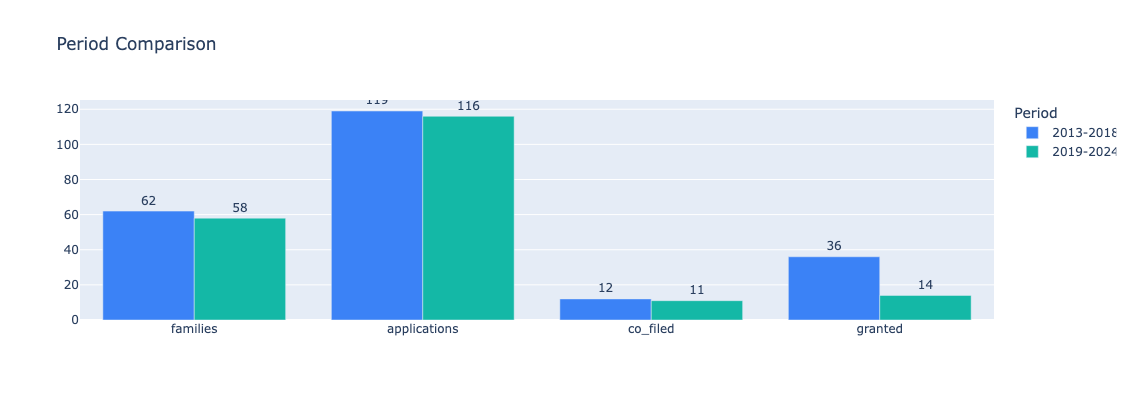

In [30]:
m = df2.melt(id_vars='period', value_vars=['families', 'applications', 'co_filed', 'granted'],
             var_name='metric', value_name='count')
fig2 = px.bar(m, x='metric', y='count', color='period', barmode='group',
    title='Period Comparison', text='count', height=400,
    color_discrete_map={'2013-2018': C['p1'], '2019-2024': C['p2']},
    labels={'count': '', 'metric': '', 'period': 'Period'})
fig2.update_traces(textposition='outside')
fig2.show()

---
## 3. Filing Activity Over Time
12-year timeline — bar chart with ESC transition marker.

In [31]:
df3 = q(TU_CTE + """
SELECT appln_filing_year AS year,
    COUNT(DISTINCT docdb_family_id) AS families,
    COUNT(DISTINCT appln_id) AS applications,
    COUNT(DISTINCT CASE WHEN nb_applicants > 1 THEN docdb_family_id END) AS co_filed,
    COUNT(DISTINCT CASE WHEN granted = 'Y' THEN appln_id END) AS granted
FROM tu GROUP BY 1 ORDER BY 1
""")
df3

0.43s | 12 rows


,year,families,applications,co_filed,granted
0,2013,9,13,2,4
1,2014,15,18,4,5
2,2015,13,20,1,7
3,2016,17,21,3,6
4,2017,22,25,2,8
5,2018,17,22,2,6
6,2019,15,21,2,5
7,2020,14,22,4,3
8,2021,13,17,2,1
9,2022,15,23,4,2


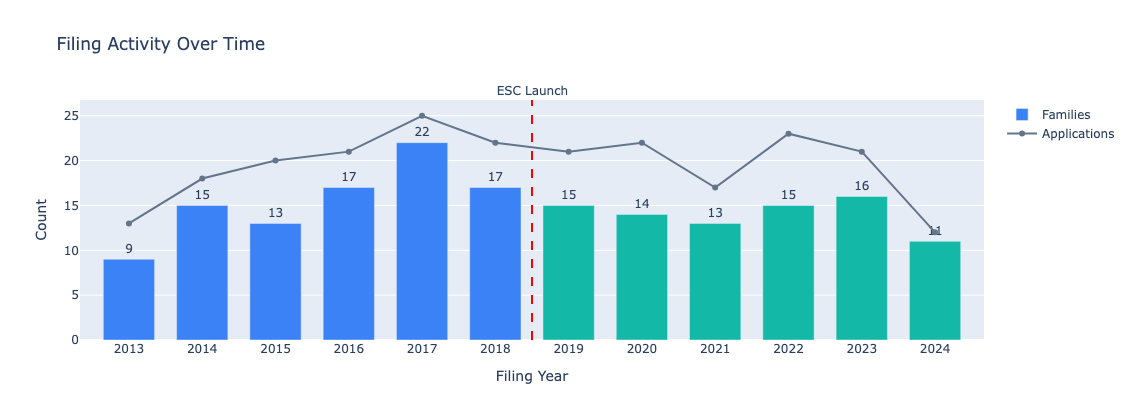

In [32]:
# Stacked bar (families) + line overlay (applications) — matching report style
colors = [C['p1'] if y <= 2018 else C['p2'] for y in df3['year']]

fig3 = go.Figure()
fig3.add_bar(x=df3['year'], y=df3['families'], name='Families',
    marker_color=colors, text=df3['families'], textposition='outside')
fig3.add_scatter(x=df3['year'], y=df3['applications'], name='Applications',
    mode='lines+markers', line=dict(color=C['gray'], width=2),
    marker=dict(size=6))
fig3.add_vline(x=2018.5, line_dash='dash', line_color='red',
    annotation_text='ESC Launch', annotation_position='top')
fig3.update_layout(title='Filing Activity Over Time', height=420,
    xaxis_title='Filing Year', yaxis_title='Count',
    xaxis=dict(dtick=1), bargap=0.3)
fig3.show()

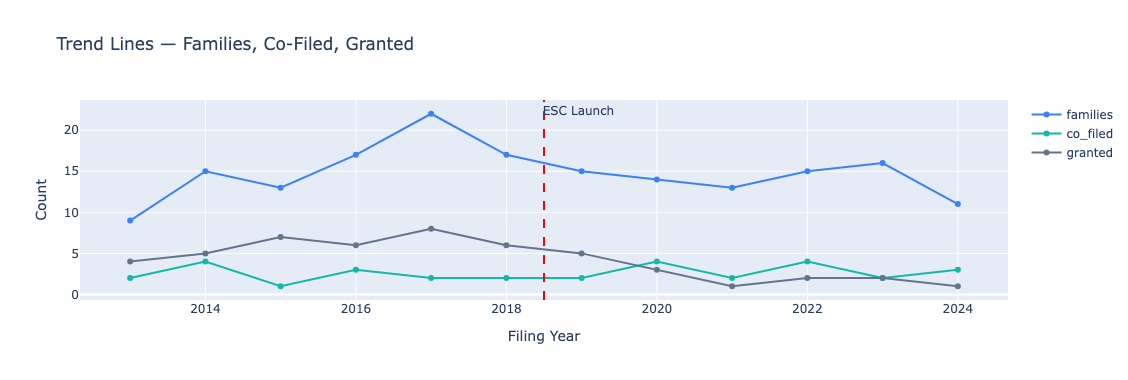

In [33]:
fig3b = px.line(df3, x='year', y=['families', 'co_filed', 'granted'],
    title='Trend Lines — Families, Co-Filed, Granted',
    labels={'year': 'Filing Year', 'value': 'Count', 'variable': ''},
    markers=True, height=380,
    color_discrete_sequence=[C['p1'], C['p2'], C['gray']])
fig3b.add_vline(x=2018.5, line_dash='dash', line_color='red',
    annotation_text='ESC Launch')
fig3b.show()

In [34]:
# Period averages
p1 = df3[df3['year'] <= 2018]['families']
p2 = df3[df3['year'] > 2018]['families']
HTML(f'<div style="border-left:4px solid {C["p2"]};padding:12px 16px;background:#f0fdfa;'
     f'border-radius:0 8px 8px 0;margin:8px 0">'
     f'<b>Insight:</b> Average families/year: <b>{p1.mean():.1f}</b> (2013–18) → '
     f'<b>{p2.mean():.1f}</b> (2019–24). '
     f'Filing volume {"stable" if abs(p1.mean()-p2.mean())<3 else "shifted"}. '
     f'Peak: {df3.loc[df3["families"].idxmax(), "year"]} '
     f'({df3["families"].max()} families).</div>')